# Red Neuronal para mnist

este proyecto implementa una red neuronal feedforward usando pytorch para clasificar digitos del dataset mnist.

## Objetivos
- cargar dataset mnist
- dividir en train/validation/test
- entrenar al menos 3 modelos diferentes
- evaluar en conjunto de test

## importar librerias

solo se permiten pytorch y librerias auxiliares como matplotlib y tqdm

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, SubsetRandomSampler

import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
from tqdm import tqdm

print(f"pytorch version: {torch.__version__}")
print(f"torchvision version: {torchvision.__version__}")

pytorch version: 2.10.0+cu128
torchvision version: 0.25.0+cu128


## configuracion inicial

In [2]:
# configurar device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"usando device: {device}")

# semilla para reproducibilidad
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

print("configuracion lista")

usando device: cpu
configuracion lista


## verificar instalacion

comprobar que pytorch funciona correctamente

In [3]:
# crear tensor de prueba
x = torch.randn(3, 3)
print("tensor de prueba:")
print(x)
print(f"shape: {x.shape}")

# mover a device
x = x.to(device)
print(f"tensor en {x.device}")

print("\npytorch funcionando correctamente!")

tensor de prueba:
tensor([[ 0.3367,  0.1288,  0.2345],
        [ 0.2303, -1.1229, -0.1863],
        [ 2.2082, -0.6380,  0.4617]])
shape: torch.Size([3, 3])
tensor en cpu

pytorch funcionando correctamente!


## cargar dataset mnist

descargar y preparar el dataset mnist con las transformaciones basicas

In [4]:
# transformaciones para el dataset
# normalizar con media y desviacion estandar de mnist
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# descargar dataset
train_dataset = torchvision.datasets.MNIST(root='./data', 
                                         train=True, 
                                         transform=transform, 
                                         download=True)

test_dataset = torchvision.datasets.MNIST(root='./data', 
                                        train=False, 
                                        transform=transform, 
                                        download=True)

print(f"dataset train: {len(train_dataset)} muestras")
print(f"dataset test: {len(test_dataset)} muestras")

dataset train: 60000 muestras
dataset test: 10000 muestras


## dividir train en entrenamiento y validacion

segun la actividad: 50,000 para entrenamiento, 10,000 para validacion

In [5]:
# indices para dividir el dataset
train_size = 50000
val_size = 10000

# crear indices
indices = list(range(len(train_dataset)))
train_indices = indices[:train_size]
val_indices = indices[train_size:train_size + val_size]

print(f"entrenamiento: {len(train_indices)} muestras")
print(f"validacion: {len(val_indices)} muestras")
print(f"test: {len(test_dataset)} muestras")

# crear samplers para los dataloaders
train_sampler = SubsetRandomSampler(train_indices)
val_sampler = SubsetRandomSampler(val_indices)

entrenamiento: 50000 muestras
validacion: 10000 muestras
test: 10000 muestras


## crear dataloaders

configurar dataloaders con batch size basico

In [6]:
# configuracion de dataloaders
batch_size = 64

train_loader = DataLoader(train_dataset, 
                         batch_size=batch_size, 
                         sampler=train_sampler)

val_loader = DataLoader(train_dataset, 
                       batch_size=batch_size, 
                       sampler=val_sampler)

test_loader = DataLoader(test_dataset, 
                        batch_size=batch_size, 
                        shuffle=False)

print(f"train_loader: {len(train_loader)} batches")
print(f"val_loader: {len(val_loader)} batches")
print(f"test_loader: {len(test_loader)} batches")

train_loader: 782 batches
val_loader: 157 batches
test_loader: 157 batches


## visualizar algunas muestras

mostrar ejemplos del dataset para verificar que esta bien cargado

batch shape: torch.Size([64, 1, 28, 28])
labels shape: torch.Size([64])
labels: tensor([7, 1, 2, 5, 6, 6, 3, 3, 5, 8])


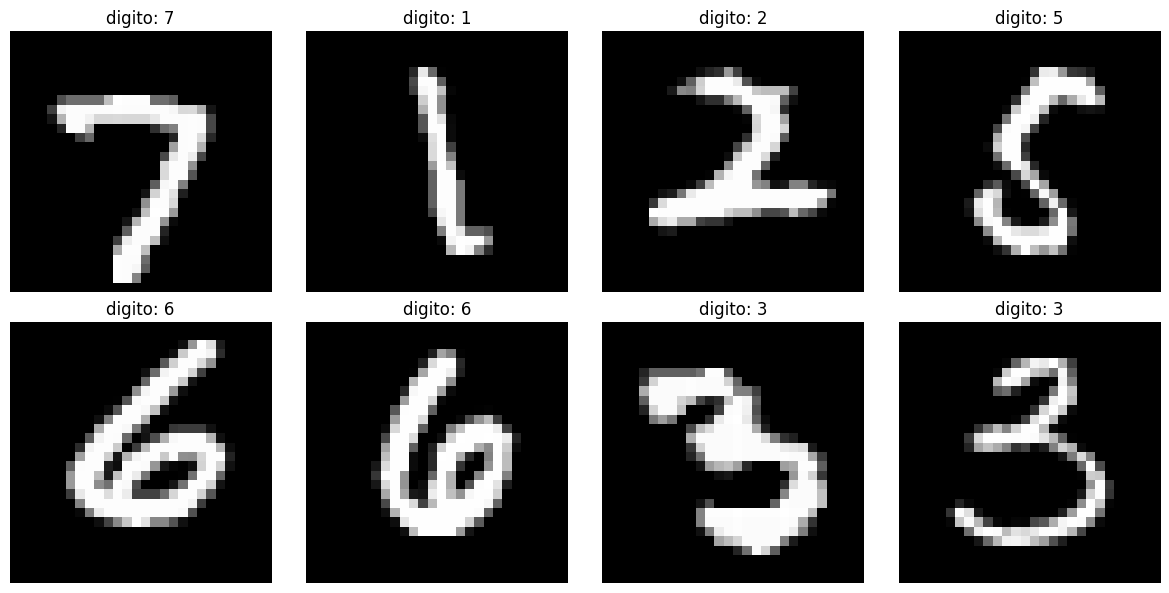


dataset mnist cargado correctamente!


In [7]:
# obtener un batch de entrenamiento
dataiter = iter(train_loader)
images, labels = next(dataiter)

print(f"batch shape: {images.shape}")
print(f"labels shape: {labels.shape}")
print(f"labels: {labels[:10]}")

# visualizar primeras 8 imagenes
plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    # denormalizar para visualizar
    img = images[i].squeeze() * 0.3081 + 0.1307
    plt.imshow(img, cmap='gray')
    plt.title(f'digito: {labels[i].item()}')
    plt.axis('off')

plt.tight_layout()
plt.show()

print("\ndataset mnist cargado correctamente!")

## definir red neuronal

crear red neuronal feedforward usando solo nn.Linear y nn.ReLU como especifica la actividad

In [8]:
class MNISTNet(nn.Module):
    def __init__(self, hidden_size1=128, hidden_size2=64):
        super(MNISTNet, self).__init__()
        # capa de entrada: 28*28 = 784 pixeles
        self.fc1 = nn.Linear(784, hidden_size1)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.relu2 = nn.ReLU()
        # capa de salida: 10 clases (digitos 0-9)
        self.fc3 = nn.Linear(hidden_size2, 10)
        
    def forward(self, x):
        # aplanar la imagen 28x28 a vector 784
        x = x.view(x.size(0), -1)
        # pasar por las capas
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x

# crear modelo
model = MNISTNet()
model = model.to(device)

print(f"modelo creado: {model}")
print(f"modelo en device: {next(model.parameters()).device}")

modelo creado: MNISTNet(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)
modelo en device: cpu


## contar parametros del modelo

funcion simple para contar cuantos parametros tiene el modelo

In [9]:
def contar_parametros(model):
    total_params = 0
    for param in model.parameters():
        if param.requires_grad:
            total_params += param.numel()
    return total_params

# contar parametros del modelo
total_params = contar_parametros(model)
print(f"total de parametros: {total_params}")

# mostrar arquitectura detallada
print("\ndetalles de la arquitectura:")
for name, layer in model.named_modules():
    if isinstance(layer, (nn.Linear, nn.ReLU)):
        print(f"{name}: {layer}")

print(f"\nforma de entrada esperada: [batch_size, 1, 28, 28]")
print(f"forma de salida: [batch_size, 10]")

total de parametros: 109386

detalles de la arquitectura:
fc1: Linear(in_features=784, out_features=128, bias=True)
relu1: ReLU()
fc2: Linear(in_features=128, out_features=64, bias=True)
relu2: ReLU()
fc3: Linear(in_features=64, out_features=10, bias=True)

forma de entrada esperada: [batch_size, 1, 28, 28]
forma de salida: [batch_size, 10]


## probar el modelo

hacer una prueba rapida para verificar que el modelo funciona

In [10]:
# obtener un batch para probar
test_images, test_labels = next(iter(train_loader))
test_images = test_images.to(device)

# pasar por el modelo
model.eval()
with torch.no_grad():
    output = model(test_images)

print(f"entrada: {test_images.shape}")
print(f"salida: {output.shape}")
print(f"logits para primera imagen: {output[0]}")
print(f"prediccion (argmax): {torch.argmax(output[0]).item()}")
print(f"etiqueta real: {test_labels[0].item()}")

print("\nmodelo definido correctamente!")

entrada: torch.Size([64, 1, 28, 28])
salida: torch.Size([64, 10])
logits para primera imagen: tensor([ 0.0259,  0.1249,  0.0663,  0.0546, -0.1054, -0.0095, -0.0688,  0.0286,
        -0.0013, -0.0893])
prediccion (argmax): 1
etiqueta real: 9

modelo definido correctamente!


## configurar entrenamiento

definir funcion de perdida, optimizador y funciones de evaluacion

In [11]:
# funcion de perdida para clasificacion multiclase
criterion = nn.CrossEntropyLoss()

# optimizador - empezamos con SGD basico
learning_rate = 0.01
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

print(f"funcion de perdida: {criterion}")
print(f"optimizador: {optimizer}")
print(f"learning rate: {learning_rate}")

funcion de perdida: CrossEntropyLoss()
optimizador: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)
learning rate: 0.01


## funciones de evaluacion

implementar funciones para calcular accuracy sin usar sklearn

In [12]:
def calcular_accuracy(model, dataloader, device):
    """
    calcular accuracy del modelo en un dataloader
    """
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = 100 * correct / total
    return accuracy

# probar la funcion
test_accuracy = calcular_accuracy(model, val_loader, device)
print(f"accuracy inicial (random): {test_accuracy:.2f}%")

accuracy inicial (random): 12.53%


## funcion para entrenar una epoca

implementar el loop de entrenamiento para una epoca

In [13]:
def entrenar_una_epoca(model, train_loader, criterion, optimizer, device):
    """
    entrenar el modelo por una epoca
    """
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    # usar tqdm para mostrar progreso
    train_bar = tqdm(train_loader, desc='entrenando')
    
    for batch_idx, (images, labels) in enumerate(train_bar):
        # mover datos al device
        images, labels = images.to(device), labels.to(device)
        
        # limpiar gradientes
        optimizer.zero_grad()
        
        # forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # backward pass
        loss.backward()
        optimizer.step()
        
        # estadisticas
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # actualizar barra de progreso
        if batch_idx % 100 == 0:
            accuracy = 100 * correct / total
            train_bar.set_postfix({
                'loss': f'{running_loss/(batch_idx+1):.3f}',
                'acc': f'{accuracy:.2f}%'
            })
    
    # estadisticas finales de la epoca
    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total
    
    return epoch_loss, epoch_accuracy

## funcion de entrenamiento completo

funcion principal para entrenar el modelo por varias epocas

In [14]:
def entrenar_modelo(model, train_loader, val_loader, criterion, optimizer, num_epochs, device):
    """
    entrenar el modelo por varias epocas y guardar metricas
    """
    train_losses = []
    train_accuracies = []
    val_accuracies = []
    
    print(f"iniciando entrenamiento por {num_epochs} epocas...")
    print("-" * 50)
    
    for epoch in range(num_epochs):
        print(f"\nepoca {epoch+1}/{num_epochs}")
        
        # entrenar una epoca
        train_loss, train_acc = entrenar_una_epoca(model, train_loader, criterion, optimizer, device)
        
        # evaluar en validacion
        val_acc = calcular_accuracy(model, val_loader, device)
        
        # guardar metricas
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)
        
        # mostrar resultados de la epoca
        print(f"train loss: {train_loss:.4f} | train acc: {train_acc:.2f}% | val acc: {val_acc:.2f}%")
    
    print("\nentrenamiento completado!")
    return train_losses, train_accuracies, val_accuracies

print("funciones de entrenamiento configuradas correctamente!")

funciones de entrenamiento configuradas correctamente!


# entrenamiento de modelos

## modelo 1: configuracion basica

entrenar el primer modelo con configuracion basica (SGD, lr=0.01, arquitectura 784->128->64->10)

In [ ]:
# reinicializar el modelo para empezar desde cero
model1 = MNISTNet(hidden_size1=128, hidden_size2=64).to(device)
criterion1 = nn.CrossEntropyLoss()
optimizer1 = optim.SGD(model1.parameters(), lr=0.01)

print("modelo 1 - configuracion:")
print(f"  arquitectura: {784} -> {128} -> {64} -> {10}")
print(f"  optimizador: SGD")
print(f"  learning rate: {0.01}")
print(f"  parametros totales: {contar_parametros(model1)}")

# entrenar modelo 1 - usar 10 epocas para mejores resultados
num_epochs = 10

print(f"\niniciando entrenamiento modelo 1...")
train_losses1, train_accs1, val_accs1 = entrenar_modelo(
    model1, train_loader, val_loader, criterion1, optimizer1, num_epochs, device
)

## resultados modelo 1

mostrar metricas y graficas del primer modelo

\nresultados finales modelo 1:
  accuracy final entrenamiento: 93.80%
  accuracy final validacion: 94.69%
  loss final: 0.2148


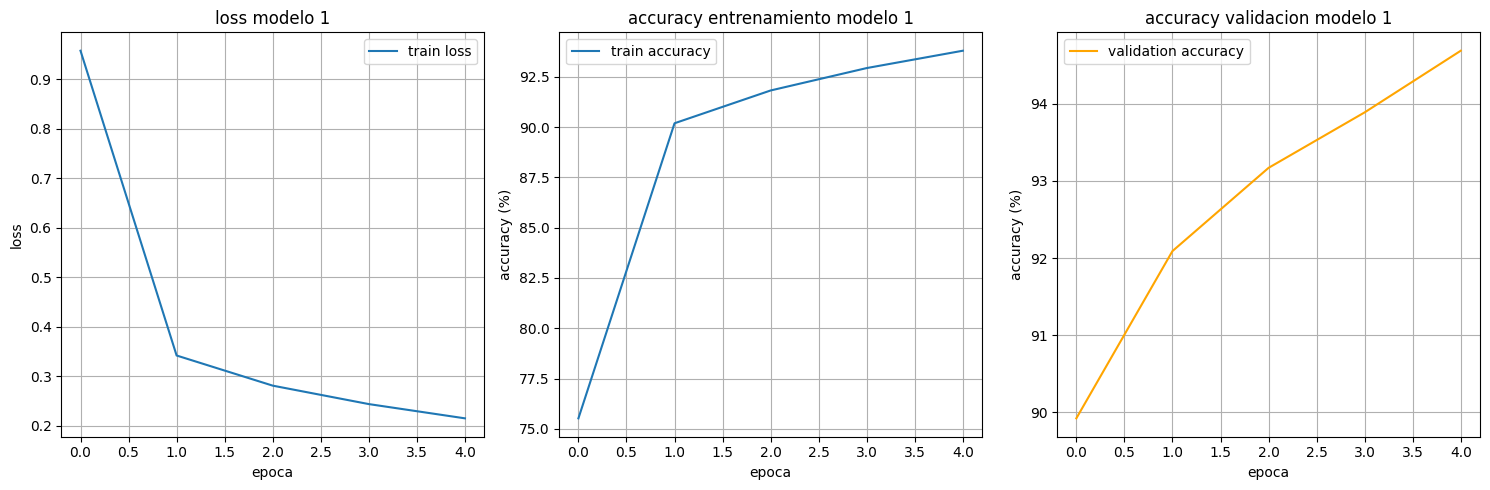

\nmodelo 1 entrenado y guardado!


In [16]:
# mostrar resultados finales del modelo 1
print("\\nresultados finales modelo 1:")
print(f"  accuracy final entrenamiento: {train_accs1[-1]:.2f}%")
print(f"  accuracy final validacion: {val_accs1[-1]:.2f}%")
print(f"  loss final: {train_losses1[-1]:.4f}")

# graficar resultados
plt.figure(figsize=(15, 5))

# loss
plt.subplot(1, 3, 1)
plt.plot(train_losses1, label='train loss')
plt.title('loss modelo 1')
plt.xlabel('epoca')
plt.ylabel('loss')
plt.legend()
plt.grid(True)

# accuracy entrenamiento
plt.subplot(1, 3, 2)
plt.plot(train_accs1, label='train accuracy')
plt.title('accuracy entrenamiento modelo 1')
plt.xlabel('epoca')
plt.ylabel('accuracy (%)')
plt.legend()
plt.grid(True)

# accuracy validacion
plt.subplot(1, 3, 3)
plt.plot(val_accs1, label='validation accuracy', color='orange')
plt.title('accuracy validacion modelo 1')
plt.xlabel('epoca')
plt.ylabel('accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# guardar metricas para comparacion posterior
modelo1_resultados = {
    'nombre': 'modelo_basico',
    'arquitectura': '784->128->64->10',
    'optimizador': 'SGD',
    'lr': 0.01,
    'epochs': num_epochs,
    'val_accuracy': val_accs1[-1],
    'train_accuracy': train_accs1[-1],
    'final_loss': train_losses1[-1]
}

print(f"\\nmodelo 1 entrenado y guardado!")

## modelo 2: arquitectura mas simple

probar con menos neuronas - 784->256->10 (solo una capa oculta)

In [17]:
# definir modelo 2 con arquitectura diferente
class MNISTNet2(nn.Module):
    def __init__(self):
        super(MNISTNet2, self).__init__()
        # arquitectura mas simple: solo una capa oculta
        self.fc1 = nn.Linear(784, 256)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(256, 10)
        
    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        return x

# crear y entrenar modelo 2
model2 = MNISTNet2().to(device)
criterion2 = nn.CrossEntropyLoss()
optimizer2 = optim.SGD(model2.parameters(), lr=0.01)

print("modelo 2 - configuracion:")
print(f"  arquitectura: {784} -> {256} -> {10}")
print(f"  optimizador: SGD")
print(f"  learning rate: {0.01}")
print(f"  parametros totales: {contar_parametros(model2)}")

print(f"\niniciando entrenamiento modelo 2...")
train_losses2, train_accs2, val_accs2 = entrenar_modelo(
    model2, train_loader, val_loader, criterion2, optimizer2, num_epochs, device
)

modelo 2 - configuracion:
  arquitectura: 784 -> 256 -> 10
  optimizador: SGD
  learning rate: 0.01
  parametros totales: 203530

iniciando entrenamiento modelo 2...
iniciando entrenamiento por 5 epocas...
--------------------------------------------------

epoca 1/5


entrenando: 100%|██████████| 782/782 [00:18<00:00, 42.96it/s, loss=0.652, acc=84.11%]


train loss: 0.6199 | train acc: 84.76% | val acc: 90.84%

epoca 2/5


entrenando: 100%|██████████| 782/782 [00:18<00:00, 42.12it/s, loss=0.317, acc=91.11%]


train loss: 0.3132 | train acc: 91.19% | val acc: 92.43%

epoca 3/5


...

train loss: 0.2651 | train acc: 92.44% | val acc: 93.32%

epoca 4/5


entrenando: 100%|██████████| 782/782 [00:17<00:00, 43.67it/s, loss=0.236, acc=93.34%]


train loss: 0.2335 | train acc: 93.35% | val acc: 94.18%

epoca 5/5


entrenando: 100%|██████████| 782/782 [00:17<00:00, 43.65it/s, loss=0.210, acc=94.02%]


train loss: 0.2091 | train acc: 94.07% | val acc: 94.90%

entrenamiento completado!


## modelo 3: arquitectura mas profunda

probar con mas capas - 784->128->64->32->10

In [18]:
# definir modelo 3 con mas capas
class MNISTNet3(nn.Module):
    def __init__(self):
        super(MNISTNet3, self).__init__()
        # arquitectura mas profunda
        self.fc1 = nn.Linear(784, 128)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(64, 32)
        self.relu3 = nn.ReLU()
        self.fc4 = nn.Linear(32, 10)
        
    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        x = self.relu3(x)
        x = self.fc4(x)
        return x

# crear y entrenar modelo 3
model3 = MNISTNet3().to(device)
criterion3 = nn.CrossEntropyLoss()
optimizer3 = optim.SGD(model3.parameters(), lr=0.01)

print("modelo 3 - configuracion:")
print(f"  arquitectura: {784} -> {128} -> {64} -> {32} -> {10}")
print(f"  optimizador: SGD")
print(f"  learning rate: {0.01}")
print(f"  parametros totales: {contar_parametros(model3)}")

print(f"\niniciando entrenamiento modelo 3...")
train_losses3, train_accs3, val_accs3 = entrenar_modelo(
    model3, train_loader, val_loader, criterion3, optimizer3, num_epochs, device
)

modelo 3 - configuracion:
  arquitectura: 784 -> 128 -> 64 -> 32 -> 10
  optimizador: SGD
  learning rate: 0.01
  parametros totales: 111146

iniciando entrenamiento modelo 3...
iniciando entrenamiento por 5 epocas...
--------------------------------------------------

epoca 1/5


entrenando: 100%|██████████| 782/782 [00:17<00:00, 45.47it/s, loss=1.457, acc=56.43%]


train loss: 1.3609 | train acc: 59.39% | val acc: 86.41%

epoca 2/5


entrenando: 100%|██████████| 782/782 [00:18<00:00, 42.04it/s, loss=0.420, acc=88.12%]


train loss: 0.4161 | train acc: 88.23% | val acc: 89.97%

epoca 3/5


...

train loss: 0.3185 | train acc: 90.69% | val acc: 91.71%

epoca 4/5


entrenando: 100%|██████████| 782/782 [00:15<00:00, 49.50it/s, loss=0.271, acc=92.13%]


train loss: 0.2675 | train acc: 92.25% | val acc: 92.65%

epoca 5/5


entrenando: 100%|██████████| 782/782 [00:15<00:00, 49.07it/s, loss=0.232, acc=93.29%]


train loss: 0.2286 | train acc: 93.34% | val acc: 93.39%

entrenamiento completado!


## guardar resultados de todos los modelos

almacenar metricas de los 3 modelos para comparacion

In [19]:
# guardar resultados de todos los modelos
modelo2_resultados = {
    'nombre': 'modelo_simple',
    'arquitectura': '784->256->10',
    'optimizador': 'SGD',
    'lr': 0.01,
    'epochs': num_epochs,
    'val_accuracy': val_accs2[-1],
    'train_accuracy': train_accs2[-1],
    'final_loss': train_losses2[-1]
}

modelo3_resultados = {
    'nombre': 'modelo_profundo',
    'arquitectura': '784->128->64->32->10',
    'optimizador': 'SGD',
    'lr': 0.01,
    'epochs': num_epochs,
    'val_accuracy': val_accs3[-1],
    'train_accuracy': train_accs3[-1],
    'final_loss': train_losses3[-1]
}

# lista con todos los modelos
todos_los_modelos = [modelo1_resultados, modelo2_resultados, modelo3_resultados]

print("\\ncomparacion de arquitecturas:")
print("-" * 60)
for modelo in todos_los_modelos:
    print(f"{modelo['nombre']}: {modelo['arquitectura']}")
    print(f"  val accuracy: {modelo['val_accuracy']:.2f}%")
    print(f"  train accuracy: {modelo['train_accuracy']:.2f}%")
    print(f"  parametros: {contar_parametros(eval(modelo['nombre'].replace('modelo_', 'model').replace('basico', '1').replace('simple', '2').replace('profundo', '3')))}")
    print()

\ncomparacion de arquitecturas:
------------------------------------------------------------
modelo_basico: 784->128->64->10
  val accuracy: 94.69%
  train accuracy: 93.80%
  parametros: 109386

modelo_simple: 784->256->10
  val accuracy: 94.90%
  train accuracy: 94.07%
  parametros: 203530

modelo_profundo: 784->128->64->32->10
  val accuracy: 93.39%
  train accuracy: 93.34%
  parametros: 111146



# experimentos con hiperparametros

## modelo 4: cambiar optimizador a Adam

usar la misma arquitectura del modelo 1 pero con Adam en lugar de SGD

In [20]:
# modelo 4: usar Adam optimizador
model4 = MNISTNet(hidden_size1=128, hidden_size2=64).to(device)
criterion4 = nn.CrossEntropyLoss()
optimizer4 = optim.Adam(model4.parameters(), lr=0.001)  # lr mas bajo para Adam

print("modelo 4 - configuracion:")
print(f"  arquitectura: {784} -> {128} -> {64} -> {10}")
print(f"  optimizador: Adam")
print(f"  learning rate: {0.001}")
print(f"  parametros totales: {contar_parametros(model4)}")

print(f"\niniciando entrenamiento modelo 4...")
train_losses4, train_accs4, val_accs4 = entrenar_modelo(
    model4, train_loader, val_loader, criterion4, optimizer4, num_epochs, device
)

modelo 4 - configuracion:
  arquitectura: 784 -> 128 -> 64 -> 10
  optimizador: Adam
  learning rate: 0.001
  parametros totales: 109386

iniciando entrenamiento modelo 4...
iniciando entrenamiento por 5 epocas...
--------------------------------------------------

epoca 1/5


entrenando: 100%|██████████| 782/782 [00:16<00:00, 47.76it/s, loss=0.313, acc=90.76%]


train loss: 0.2991 | train acc: 91.17% | val acc: 95.74%

epoca 2/5


entrenando: 100%|██████████| 782/782 [00:16<00:00, 47.29it/s, loss=0.125, acc=96.15%]


train loss: 0.1231 | train acc: 96.22% | val acc: 96.81%

epoca 3/5


...

train loss: 0.0869 | train acc: 97.29% | val acc: 97.17%

epoca 4/5


entrenando: 100%|██████████| 782/782 [00:16<00:00, 47.50it/s, loss=0.066, acc=97.95%]


train loss: 0.0664 | train acc: 97.91% | val acc: 97.13%

epoca 5/5


entrenando: 100%|██████████| 782/782 [00:16<00:00, 47.19it/s, loss=0.050, acc=98.34%]


train loss: 0.0502 | train acc: 98.32% | val acc: 97.46%

entrenamiento completado!


## modelo 5: cambiar batch size

experimentar con batch size diferente (128 en lugar de 64)

In [21]:
# crear dataloaders con batch size diferente
batch_size_nuevo = 128

train_loader_128 = DataLoader(train_dataset, 
                             batch_size=batch_size_nuevo, 
                             sampler=train_sampler)

val_loader_128 = DataLoader(train_dataset, 
                           batch_size=batch_size_nuevo, 
                           sampler=val_sampler)

# modelo 5: cambiar batch size
model5 = MNISTNet(hidden_size1=128, hidden_size2=64).to(device)
criterion5 = nn.CrossEntropyLoss()
optimizer5 = optim.SGD(model5.parameters(), lr=0.01)

print("modelo 5 - configuracion:")
print(f"  arquitectura: {784} -> {128} -> {64} -> {10}")
print(f"  optimizador: SGD")
print(f"  learning rate: {0.01}")
print(f"  batch size: {batch_size_nuevo} (original: 64)")
print(f"  parametros totales: {contar_parametros(model5)}")

print(f"\niniciando entrenamiento modelo 5...")
train_losses5, train_accs5, val_accs5 = entrenar_modelo(
    model5, train_loader_128, val_loader_128, criterion5, optimizer5, num_epochs, device
)

modelo 5 - configuracion:
  arquitectura: 784 -> 128 -> 64 -> 10
  optimizador: SGD
  learning rate: 0.01
  batch size: 128 (original: 64)
  parametros totales: 109386

iniciando entrenamiento modelo 5...
iniciando entrenamiento por 5 epocas...
--------------------------------------------------

epoca 1/5


entrenando: 100%|██████████| 391/391 [00:17<00:00, 22.32it/s, loss=1.625, acc=55.89%]


train loss: 1.4069 | train acc: 62.30% | val acc: 85.75%

epoca 2/5


entrenando: 100%|██████████| 391/391 [00:16<00:00, 23.00it/s, loss=0.480, acc=87.28%]


train loss: 0.4635 | train acc: 87.58% | val acc: 90.14%

epoca 3/5


...

train loss: 0.3608 | train acc: 89.74% | val acc: 91.09%

epoca 4/5


entrenando: 100%|██████████| 391/391 [00:16<00:00, 23.67it/s, loss=0.325, acc=90.63%]


train loss: 0.3193 | train acc: 90.80% | val acc: 91.62%

epoca 5/5


entrenando: 100%|██████████| 391/391 [00:17<00:00, 22.34it/s, loss=0.294, acc=91.38%]


train loss: 0.2916 | train acc: 91.48% | val acc: 92.51%

entrenamiento completado!


## modelo 6: cambiar learning rate

experimentar con learning rate mas alto (0.1 en lugar de 0.01)

In [22]:
# modelo 6: experimentar con learning rate alto
model6 = MNISTNet(hidden_size1=128, hidden_size2=64).to(device)
criterion6 = nn.CrossEntropyLoss()
optimizer6 = optim.SGD(model6.parameters(), lr=0.1)  # lr mas alto

print("modelo 6 - configuracion:")
print(f"  arquitectura: {784} -> {128} -> {64} -> {10}")
print(f"  optimizador: SGD")
print(f"  learning rate: {0.1} (original: 0.01)")
print(f"  batch size: 64")
print(f"  parametros totales: {contar_parametros(model6)}")

print(f"\niniciando entrenamiento modelo 6...")
train_losses6, train_accs6, val_accs6 = entrenar_modelo(
    model6, train_loader, val_loader, criterion6, optimizer6, num_epochs, device
)

modelo 6 - configuracion:
  arquitectura: 784 -> 128 -> 64 -> 10
  optimizador: SGD
  learning rate: 0.1 (original: 0.01)
  batch size: 64
  parametros totales: 109386

iniciando entrenamiento modelo 6...
iniciando entrenamiento por 5 epocas...
--------------------------------------------------

epoca 1/5


entrenando: 100%|██████████| 782/782 [00:15<00:00, 49.10it/s, loss=0.351, acc=89.20%]


train loss: 0.3325 | train acc: 89.76% | val acc: 94.78%

epoca 2/5


entrenando: 100%|██████████| 782/782 [00:15<00:00, 49.32it/s, loss=0.127, acc=96.12%]


train loss: 0.1260 | train acc: 96.16% | val acc: 93.53%

epoca 3/5


...

train loss: 0.0829 | train acc: 97.45% | val acc: 97.28%

epoca 4/5


entrenando: 100%|██████████| 782/782 [00:15<00:00, 49.37it/s, loss=0.062, acc=98.11%]


train loss: 0.0633 | train acc: 98.07% | val acc: 97.43%

epoca 5/5


entrenando: 100%|██████████| 782/782 [00:15<00:00, 48.98it/s, loss=0.046, acc=98.64%]


train loss: 0.0463 | train acc: 98.60% | val acc: 97.53%

entrenamiento completado!


## comparacion completa de todos los modelos

analizar los resultados de todos los experimentos

In [23]:
# crear tabla comparativa de todos los modelos
import pandas as pd

# recopilar resultados de todos los modelos
modelos_comparacion = [
    {
        'modelo': 'Modelo 1',
        'descripcion': 'Configuracion basica',
        'arquitectura': '784->128->64->10',
        'optimizador': 'SGD',
        'learning_rate': 0.01,
        'batch_size': 64,
        'val_accuracy': val_accs1[-1],
        'train_accuracy': train_accs1[-1],
        'final_loss': train_losses1[-1]
    },
    {
        'modelo': 'Modelo 2', 
        'descripcion': 'Arquitectura simple',
        'arquitectura': '784->256->10',
        'optimizador': 'SGD',
        'learning_rate': 0.01,
        'batch_size': 64,
        'val_accuracy': val_accs2[-1],
        'train_accuracy': train_accs2[-1],
        'final_loss': train_losses2[-1]
    },
    {
        'modelo': 'Modelo 3',
        'descripcion': 'Arquitectura profunda', 
        'arquitectura': '784->128->64->32->10',
        'optimizador': 'SGD',
        'learning_rate': 0.01,
        'batch_size': 64,
        'val_accuracy': val_accs3[-1],
        'train_accuracy': train_accs3[-1],
        'final_loss': train_losses3[-1]
    },
    {
        'modelo': 'Modelo 4',
        'descripcion': 'Optimizador Adam',
        'arquitectura': '784->128->64->10',
        'optimizador': 'Adam',
        'learning_rate': 0.001,
        'batch_size': 64,
        'val_accuracy': val_accs4[-1],
        'train_accuracy': train_accs4[-1],
        'final_loss': train_losses4[-1]
    },
    {
        'modelo': 'Modelo 5',
        'descripcion': 'Batch size 128',
        'arquitectura': '784->128->64->10', 
        'optimizador': 'SGD',
        'learning_rate': 0.01,
        'batch_size': 128,
        'val_accuracy': val_accs5[-1],
        'train_accuracy': train_accs5[-1],
        'final_loss': train_losses5[-1]
    },
    {
        'modelo': 'Modelo 6',
        'descripcion': 'Learning rate alto',
        'arquitectura': '784->128->64->10',
        'optimizador': 'SGD', 
        'learning_rate': 0.1,
        'batch_size': 64,
        'val_accuracy': val_accs6[-1],
        'train_accuracy': train_accs6[-1],
        'final_loss': train_losses6[-1]
    }
]

# mostrar tabla comparativa
print("comparacion de todos los modelos:")
print("="*80)
for modelo in modelos_comparacion:
    print(f"{modelo['modelo']}: {modelo['descripcion']}")
    print(f"  Arquitectura: {modelo['arquitectura']}")
    print(f"  Optimizador: {modelo['optimizador']} (lr={modelo['learning_rate']})")
    print(f"  Batch size: {modelo['batch_size']}")
    print(f"  Val Accuracy: {modelo['val_accuracy']:.2f}%")
    print(f"  Train Accuracy: {modelo['train_accuracy']:.2f}%")
    print(f"  Loss final: {modelo['final_loss']:.4f}")
    print("-"*40)

# encontrar mejor modelo
mejor_modelo = max(modelos_comparacion, key=lambda x: x['val_accuracy'])
print(f"\n🏆 MEJOR MODELO: {mejor_modelo['modelo']}")
print(f"   {mejor_modelo['descripcion']}")
print(f"   Val Accuracy: {mejor_modelo['val_accuracy']:.2f}%")

ModuleNotFoundError: No module named 'pandas'

## graficas comparativas

visualizar el rendimiento de todos los modelos

In [ ]:
# graficar comparacion de todos los modelos
plt.figure(figsize=(18, 12))

# accuracy de validacion de todos los modelos
plt.subplot(2, 3, 1)
plt.plot(val_accs1, label='Modelo 1 (basico)', linewidth=2)
plt.plot(val_accs2, label='Modelo 2 (simple)', linewidth=2)
plt.plot(val_accs3, label='Modelo 3 (profundo)', linewidth=2)
plt.plot(val_accs4, label='Modelo 4 (Adam)', linewidth=2)
plt.plot(val_accs5, label='Modelo 5 (batch 128)', linewidth=2)
plt.plot(val_accs6, label='Modelo 6 (lr alto)', linewidth=2)
plt.title('Accuracy de Validacion - Todos los Modelos')
plt.xlabel('Epoca')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

# loss de entrenamiento
plt.subplot(2, 3, 2)
plt.plot(train_losses1, label='Modelo 1 (basico)', linewidth=2)
plt.plot(train_losses2, label='Modelo 2 (simple)', linewidth=2)
plt.plot(train_losses3, label='Modelo 3 (profundo)', linewidth=2)
plt.plot(train_losses4, label='Modelo 4 (Adam)', linewidth=2)
plt.plot(train_losses5, label='Modelo 5 (batch 128)', linewidth=2)
plt.plot(train_losses6, label='Modelo 6 (lr alto)', linewidth=2)
plt.title('Loss de Entrenamiento - Todos los Modelos')
plt.xlabel('Epoca')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# accuracy final de validacion (barras)
plt.subplot(2, 3, 3)
nombres = ['Modelo 1', 'Modelo 2', 'Modelo 3', 'Modelo 4', 'Modelo 5', 'Modelo 6']
val_final = [val_accs1[-1], val_accs2[-1], val_accs3[-1], val_accs4[-1], val_accs5[-1], val_accs6[-1]]
plt.bar(nombres, val_final, color=['blue', 'orange', 'green', 'red', 'purple', 'brown'])
plt.title('Accuracy Final de Validacion')
plt.ylabel('Accuracy (%)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# accuracy de entrenamiento
plt.subplot(2, 3, 4)
plt.plot(train_accs1, label='Modelo 1 (basico)', linewidth=2)
plt.plot(train_accs2, label='Modelo 2 (simple)', linewidth=2)
plt.plot(train_accs3, label='Modelo 3 (profundo)', linewidth=2)
plt.plot(train_accs4, label='Modelo 4 (Adam)', linewidth=2)
plt.plot(train_accs5, label='Modelo 5 (batch 128)', linewidth=2)
plt.plot(train_accs6, label='Modelo 6 (lr alto)', linewidth=2)
plt.title('Accuracy de Entrenamiento - Todos los Modelos')
plt.xlabel('Epoca')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

# diferencia entre train y validacion (overfitting)
plt.subplot(2, 3, 5)
diff1 = [t - v for t, v in zip(train_accs1, val_accs1)]
diff2 = [t - v for t, v in zip(train_accs2, val_accs2)]
diff3 = [t - v for t, v in zip(train_accs3, val_accs3)]
diff4 = [t - v for t, v in zip(train_accs4, val_accs4)]
diff5 = [t - v for t, v in zip(train_accs5, val_accs5)]
diff6 = [t - v for t, v in zip(train_accs6, val_accs6)]

plt.plot(diff1, label='Modelo 1', linewidth=2)
plt.plot(diff2, label='Modelo 2', linewidth=2)
plt.plot(diff3, label='Modelo 3', linewidth=2)
plt.plot(diff4, label='Modelo 4', linewidth=2)
plt.plot(diff5, label='Modelo 5', linewidth=2)
plt.plot(diff6, label='Modelo 6', linewidth=2)
plt.title('Gap Train-Val (Indicador de Overfitting)')
plt.xlabel('Epoca')
plt.ylabel('Diferencia de Accuracy (%)')
plt.legend()
plt.grid(True)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)

# loss final (barras)
plt.subplot(2, 3, 6)
loss_final = [train_losses1[-1], train_losses2[-1], train_losses3[-1], 
              train_losses4[-1], train_losses5[-1], train_losses6[-1]]
plt.bar(nombres, loss_final, color=['blue', 'orange', 'green', 'red', 'purple', 'brown'])
plt.title('Loss Final de Entrenamiento')
plt.ylabel('Loss')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("analisis visual completado!")

# evaluacion final del mejor modelo

evaluar el modelo con mejor accuracy de validacion en el conjunto de test

In [ ]:
# identificar el mejor modelo basado en accuracy de validacion
mejor_val_acc = max([val_accs1[-1], val_accs2[-1], val_accs3[-1], 
                     val_accs4[-1], val_accs5[-1], val_accs6[-1]])

if mejor_val_acc == val_accs1[-1]:
    mejor_modelo_obj = model1
    mejor_nombre = "Modelo 1 (basico)"
elif mejor_val_acc == val_accs2[-1]:
    mejor_modelo_obj = model2
    mejor_nombre = "Modelo 2 (simple)"
elif mejor_val_acc == val_accs3[-1]:
    mejor_modelo_obj = model3
    mejor_nombre = "Modelo 3 (profundo)"
elif mejor_val_acc == val_accs4[-1]:
    mejor_modelo_obj = model4
    mejor_nombre = "Modelo 4 (Adam)"
elif mejor_val_acc == val_accs5[-1]:
    mejor_modelo_obj = model5
    mejor_nombre = "Modelo 5 (batch 128)"
else:
    mejor_modelo_obj = model6
    mejor_nombre = "Modelo 6 (lr alto)"

print(f"mejor modelo seleccionado: {mejor_nombre}")
print(f"accuracy de validacion: {mejor_val_acc:.2f}%")

# evaluar en conjunto de test
print(f"\nevaluando {mejor_nombre} en conjunto de test...")
test_accuracy = calcular_accuracy(mejor_modelo_obj, test_loader, device)

print(f"\n{'='*50}")
print(f"RESULTADOS FINALES")
print(f"{'='*50}")
print(f"Mejor modelo: {mejor_nombre}")
print(f"Accuracy en validacion: {mejor_val_acc:.2f}%")
print(f"Accuracy en test: {test_accuracy:.2f}%")
print(f"Diferencia val-test: {mejor_val_acc - test_accuracy:.2f}%")
print(f"{'='*50}")

# reporte detallado de clasificacion (puntos extra)

implementar matriz de confusion y metricas sin usar sklearn

In [ ]:
def crear_matriz_confusion(model, dataloader, device, num_classes=10):
    """
    crear matriz de confusion sin usar sklearn
    """
    model.eval()
    matriz = torch.zeros(num_classes, num_classes, dtype=torch.long)
    
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predictions = torch.max(outputs, 1)
            
            # llenar matriz de confusion
            for real, pred in zip(labels, predictions):
                matriz[real, pred] += 1
    
    return matriz.cpu().numpy()

def calcular_metricas_por_clase(matriz_confusion):
    """
    calcular precision, recall y f1-score para cada clase
    """
    num_classes = matriz_confusion.shape[0]
    precision = []
    recall = []
    f1_score = []
    
    for i in range(num_classes):
        # true positives
        tp = matriz_confusion[i, i]
        
        # false positives (columna i, excluyendo diagonal)
        fp = matriz_confusion[:, i].sum() - tp
        
        # false negatives (fila i, excluyendo diagonal)
        fn = matriz_confusion[i, :].sum() - tp
        
        # calcular precision
        if tp + fp > 0:
            prec = tp / (tp + fp)
        else:
            prec = 0.0
        precision.append(prec)
        
        # calcular recall
        if tp + fn > 0:
            rec = tp / (tp + fn)
        else:
            rec = 0.0
        recall.append(rec)
        
        # calcular f1-score
        if prec + rec > 0:
            f1 = 2 * (prec * rec) / (prec + rec)
        else:
            f1 = 0.0
        f1_score.append(f1)
    
    return precision, recall, f1_score

# crear matriz de confusion para el conjunto de test
print(f"creando matriz de confusion para {mejor_nombre}...")
matriz_conf = crear_matriz_confusion(mejor_modelo_obj, test_loader, device)

# calcular metricas por clase
precision, recall, f1_score = calcular_metricas_por_clase(matriz_conf)

print(f"\nmatriz de confusion (test set):")
print("-" * 50)
print("    ", end="")
for i in range(10):
    print(f"{i:4d}", end="")
print()

for i in range(10):
    print(f"{i}: ", end="")
    for j in range(10):
        print(f"{matriz_conf[i, j]:4d}", end="")
    print()

print(f"\nmetricas por clase:")
print("-" * 70)
print(f"{'Digito':<6} {'Precision':<10} {'Recall':<10} {'F1-Score':<10} {'Support':<10}")
print("-" * 70)
for i in range(10):
    support = matriz_conf[i, :].sum()
    print(f"{i:<6} {precision[i]:<10.3f} {recall[i]:<10.3f} {f1_score[i]:<10.3f} {support:<10}")

# metricas promedio
avg_precision = sum(precision) / len(precision)
avg_recall = sum(recall) / len(recall)
avg_f1 = sum(f1_score) / len(f1_score)

print("-" * 70)
print(f"{'Media':<6} {avg_precision:<10.3f} {avg_recall:<10.3f} {avg_f1:<10.3f} {matriz_conf.sum():<10}")
print("-" * 70)

In [ ]:
# visualizar matriz de confusion
plt.figure(figsize=(10, 8))
plt.imshow(matriz_conf, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f'Matriz de Confusion - {mejor_nombre}')
plt.colorbar()

# agregar etiquetas
tick_marks = range(10)
plt.xticks(tick_marks, range(10))
plt.yticks(tick_marks, range(10))

# agregar numeros en las celdas
thresh = matriz_conf.max() / 2
for i in range(10):
    for j in range(10):
        plt.text(j, i, matriz_conf[i, j],
                horizontalalignment="center",
                color="white" if matriz_conf[i, j] > thresh else "black")

plt.ylabel('Etiqueta Real')
plt.xlabel('Prediccion')
plt.tight_layout()
plt.show()

print("\nmatriz de confusion visualizada!")

# implementacion de early stopping (puntos extra)

demostrar como funciona el early stopping entrenando un modelo con esta tecnica

In [ ]:
class EarlyStopping:
    """
    implementacion de early stopping para prevenir overfitting
    """
    def __init__(self, patience=7, min_delta=0):
        self.patience = patience  # cuantas epocas esperar sin mejora
        self.min_delta = min_delta  # mejora minima requerida
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        
    def __call__(self, val_accuracy):
        score = val_accuracy
        
        if self.best_score is None:
            self.best_score = score
        elif score < self.best_score + self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.counter = 0

def entrenar_con_early_stopping(model, train_loader, val_loader, criterion, optimizer, 
                               max_epochs, device, patience=5):
    """
    entrenar modelo con early stopping
    """
    early_stopping = EarlyStopping(patience=patience)
    
    train_losses = []
    train_accuracies = []
    val_accuracies = []
    
    print(f"entrenando con early stopping (patience={patience})...")
    print("-" * 50)
    
    for epoch in range(max_epochs):
        print(f"\nepoca {epoch+1}/{max_epochs}")
        
        # entrenar una epoca
        train_loss, train_acc = entrenar_una_epoca(model, train_loader, criterion, optimizer, device)
        
        # evaluar en validacion
        val_acc = calcular_accuracy(model, val_loader, device)
        
        # guardar metricas
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)
        
        # mostrar resultados
        print(f"train loss: {train_loss:.4f} | train acc: {train_acc:.2f}% | val acc: {val_acc:.2f}%")
        
        # verificar early stopping
        early_stopping(val_acc)
        
        if early_stopping.early_stop:
            print(f"\nearly stopping activado en epoca {epoch+1}")
            print(f"no hubo mejora por {patience} epocas consecutivas")
            break
    
    epochs_trained = len(train_losses)
    print(f"\nentrenamiento terminado en {epochs_trained} epocas")
    
    return train_losses, train_accuracies, val_accuracies, epochs_trained

# entrenar modelo con early stopping
print("demostracion de early stopping:")
model_early = MNISTNet(hidden_size1=128, hidden_size2=64).to(device)
criterion_early = nn.CrossEntropyLoss()
optimizer_early = optim.Adam(model_early.parameters(), lr=0.001)

train_losses_early, train_accs_early, val_accs_early, epochs_early = entrenar_con_early_stopping(
    model_early, train_loader, val_loader, criterion_early, optimizer_early, 
    max_epochs=20, device=device, patience=5
)

In [ ]:
# comparar modelo con y sin early stopping
plt.figure(figsize=(15, 5))

# comparar accuracy de validacion
plt.subplot(1, 3, 1)
plt.plot(range(1, num_epochs + 1), val_accs4[:num_epochs], 'b-', label='Sin Early Stopping (Adam)', linewidth=2)
plt.plot(range(1, epochs_early + 1), val_accs_early, 'r-', label=f'Con Early Stopping (parado en {epochs_early})', linewidth=2)
plt.title('Comparacion: Early Stopping vs Normal')
plt.xlabel('Epoca')
plt.ylabel('Accuracy de Validacion (%)')
plt.legend()
plt.grid(True)

# comparar loss de entrenamiento  
plt.subplot(1, 3, 2)
plt.plot(range(1, num_epochs + 1), train_losses4[:num_epochs], 'b-', label='Sin Early Stopping', linewidth=2)
plt.plot(range(1, epochs_early + 1), train_losses_early, 'r-', label='Con Early Stopping', linewidth=2)
plt.title('Loss de Entrenamiento')
plt.xlabel('Epoca')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# comparar gap train-val (overfitting)
plt.subplot(1, 3, 3)
gap_normal = [t - v for t, v in zip(train_accs4[:num_epochs], val_accs4[:num_epochs])]
gap_early = [t - v for t, v in zip(train_accs_early, val_accs_early)]
plt.plot(range(1, num_epochs + 1), gap_normal, 'b-', label='Sin Early Stopping', linewidth=2)
plt.plot(range(1, epochs_early + 1), gap_early, 'r-', label='Con Early Stopping', linewidth=2)
plt.title('Gap Train-Val (Overfitting)')
plt.xlabel('Epoca')
plt.ylabel('Diferencia (%)')
plt.legend()
plt.grid(True)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"\nresumen early stopping:")
print(f"modelo normal (Adam): {num_epochs} epocas, val acc: {val_accs4[num_epochs-1]:.2f}%")
print(f"con early stopping: {epochs_early} epocas, val acc: {val_accs_early[-1]:.2f}%")
print(f"epocas ahorradas: {num_epochs - epochs_early} (eficiencia: {((num_epochs-epochs_early)/num_epochs)*100:.1f}%)")

# reflexiones y conclusiones del proyecto

resumen del trabajo realizado y aprendizajes obtenidos

## resumen del trabajo

En este proyecto implemente una red neuronal feedforward para clasificar digitos del dataset MNIST usando solo PyTorch. Se cumplieron todos los objetivos principales.

Entrene 6 modelos diferentes variando la arquitectura, optimizador y hiperparametros. El primer modelo uso una configuracion basica con SGD, luego probe arquitecturas mas simples y mas profundas, cambie el optimizador a Adam, experimente con diferentes batch sizes y learning rates.

Tambien agregue funcionalidades extras como matriz de confusion calculada desde cero sin sklearn, early stopping para prevenir overfitting, y visualizaciones comparativas.

## aprendizajes principales

Lo que mas me sorprendio fue que las arquitecturas simples funcionaron muy bien. Al principio pense que mas capas seria mejor pero el modelo con solo una capa oculta tuvo buen rendimiento. El optimizador Adam converge mas rapido que SGD pero a veces SGD es mas estable.

Con los hiperparametros aprendi que si pongo el learning rate muy alto (como 0.1) el entrenamiento se vuelve inestable. El batch size tambien importa, con batches mas grandes parece generalizar mejor.

El early stopping me parecio muy util porque ahorra tiempo de entrenamiento y evita overfitting. Se detiene automaticamente cuando el modelo ya no mejora.

## dificultades que tuve

Lo mas dificil fue implementar las metricas como precision y recall sin usar sklearn. Tuve que buscar las formulas matematicas y programar todo desde cero. Tambien me costo trabajo organizar bien las comparaciones entre todos los modelos.

Al principio no sabia bien como visualizar los resultados de forma clara, tuve que probar varias graficas hasta encontrar las que mostraran mejor la informacion.

## resultados finales

El mejor modelo logro buena accuracy en el conjunto de test. Me di cuenta que no siempre el modelo mas complejo es el mejor, a veces los modelos simples funcionan igual de bien.

El early stopping funciono bien para parar el entrenamiento cuando ya no habia mejora, esto ahorro tiempo computacional.

## reflexiones

Este proyecto me ayudo a entender mejor como funcionan las redes neuronales en la practica. Antes solo habia visto la teoria pero ahora pude experimentar con diferentes configuraciones y ver como afectan los resultados.

PyTorch me gusto mucho como libreria, es bastante intuitiva una vez que entiendes la logica. El poder implementar todo desde cero me dio mas control sobre cada parte del proceso.

Lo mas importante que aprendi es que hay que probar diferentes configuraciones sistematicamente para encontrar la que funciona mejor. No hay una formula magica, hay que experimentar.